In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

In [3]:
housing= fetch_california_housing()

df = pd.DataFrame(housing.data, columns= housing.feature_names)
df['MedHouseVal']=housing.target

print('Shape:', df.shape)
print('\nfirst 5 rows')
df.head()

Shape: (20640, 9)

first 5 rows


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe().round(2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


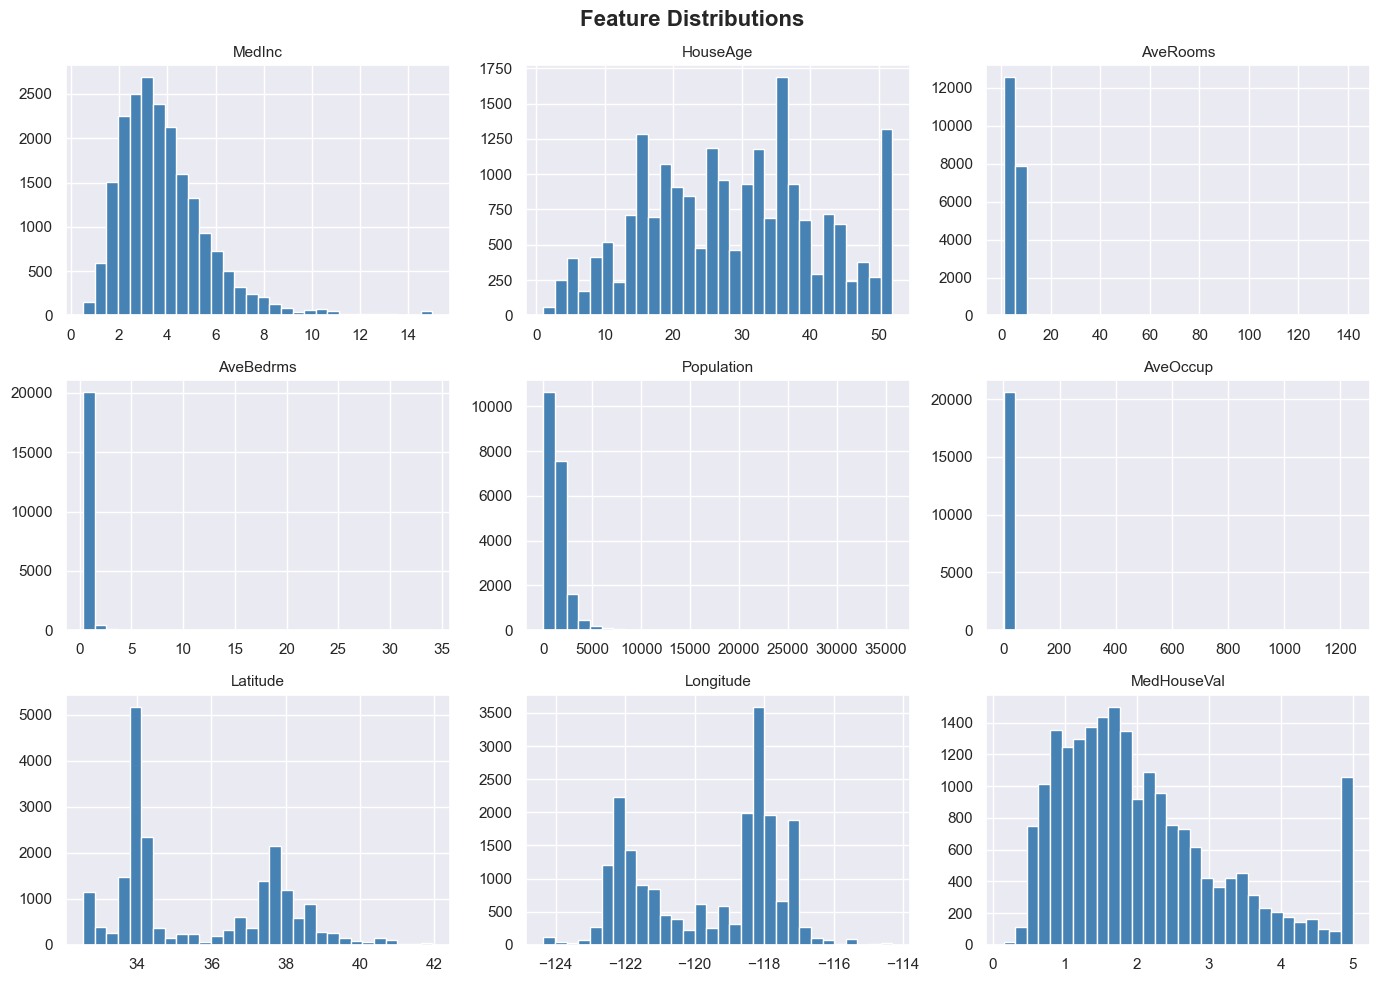

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

for i, col in enumerate(df.columns):
    ax = axes[i//3, i%3]
    df[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

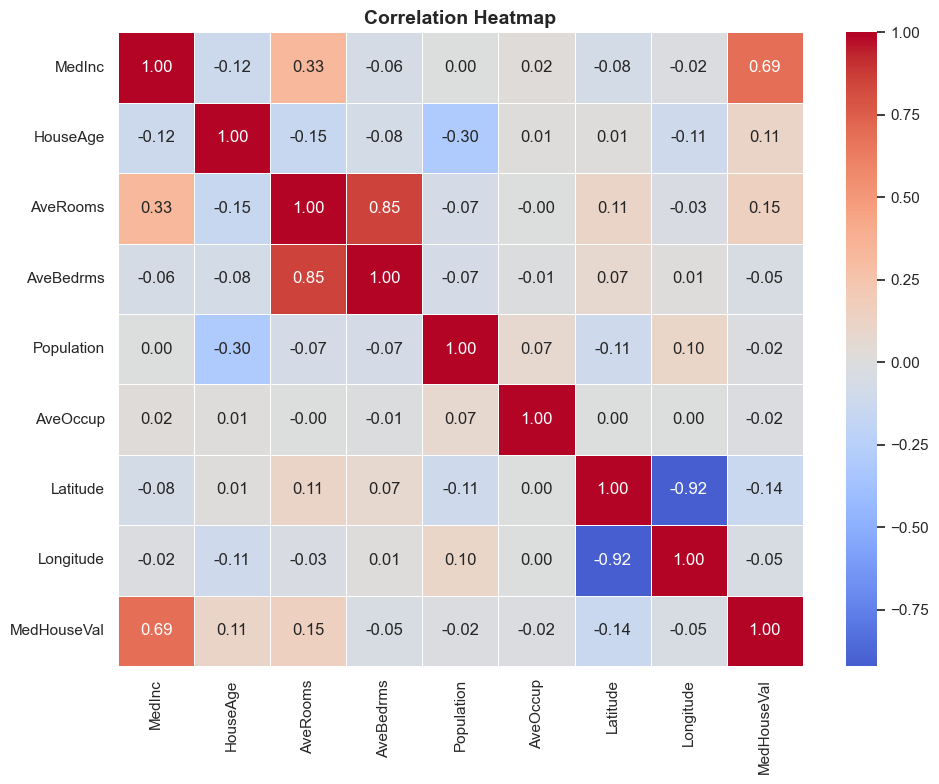

In [7]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr().round(2)

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (20640, 8)
Target shape: (20640,)

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      
    random_state=42     
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")

Training set size: (16512, 8)
Test set size: (4128, 8)

Train: 16512 rows | Test: 4128 rows


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

print("Scaling complete!")
print("Mean of first feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first feature (should be ~1):", X_train_scaled[:, 0].std().round(4))

Scaling complete!
Mean of first feature (should be ~0): -0.0
Std of first feature (should be ~1): 1.0


In [11]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("Scaled training data preview:")
X_train_scaled_df.describe().round(3)

Scaled training data preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000,16512.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.775,-2.191,-1.904,-1.762,-1.252,-0.208,-1.448,-2.377
25%,-0.690,-0.842,-0.412,-0.208,-0.561,-0.058,-0.802,-1.111
50%,-0.176,0.031,-0.084,-0.109,-0.228,-0.024,-0.647,0.535
75%,0.469,0.666,0.262,0.008,0.263,0.016,0.972,0.784
max,5.839,1.856,57.167,56.647,30.127,107.116,2.952,2.629


In [12]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("Linear Regression trained!")
print("Coefficients:", dict(zip(X.columns, lr_model.coef_.round(3))))

Linear Regression trained!
Coefficients: {'MedInc': np.float64(0.854), 'HouseAge': np.float64(0.123), 'AveRooms': np.float64(-0.294), 'AveBedrms': np.float64(0.339), 'Population': np.float64(-0.002), 'AveOccup': np.float64(-0.041), 'Latitude': np.float64(-0.897), 'Longitude': np.float64(-0.87)}


In [13]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=6,        
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree trained!")
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Decision Tree trained!
Tree depth: 6
Number of leaves: 64


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,   
    max_depth=10,
    random_state=42,
    n_jobs=-1           
)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained!")
print("Number of trees:", rf_model.n_estimators)

Random Forest trained!
Number of trees: 100


In [15]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Predictions generated for all 3 models!")
print(f"Sample LR predictions: {y_pred_lr[:5].round(2)}")
print(f"Sample DT predictions: {y_pred_dt[:5].round(2)}")
print(f"Sample RF predictions: {y_pred_rf[:5].round(2)}")
print(f"\nActual values:         {y_test.values[:5].round(2)}")

Predictions generated for all 3 models!
Sample LR predictions: [0.72 1.76 2.71 2.84 2.6 ]
Sample DT predictions: [1.11 1.15 3.79 2.31 1.51]
Sample RF predictions: [0.57 0.81 4.84 2.45 2.04]

Actual values:         [0.48 0.46 5.   2.19 2.78]


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

def evaluate_model(name, y_true, y_pred):
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    mae= mean_absolute_error(y_true,y_pred)
    r2=r2_score(y_true,y_pred)
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R² Score': round(r2, 4)}
results = pd.DataFrame([
    evaluate_model('Linear Regression', y_test,y_pred_lr),
    evaluate_model('Decision Tree',y_test, y_pred_dt),
    evaluate_model('Random Forest',y_test, y_pred_rf)
])
print("Model Comparison:")
print(results.to_string(index=False))

Model Comparison:
            Model   RMSE    MAE  R² Score
Linear Regression 0.7456 0.5332    0.5758
    Decision Tree 0.7052 0.5008    0.6205
    Random Forest 0.5443 0.3663    0.7739


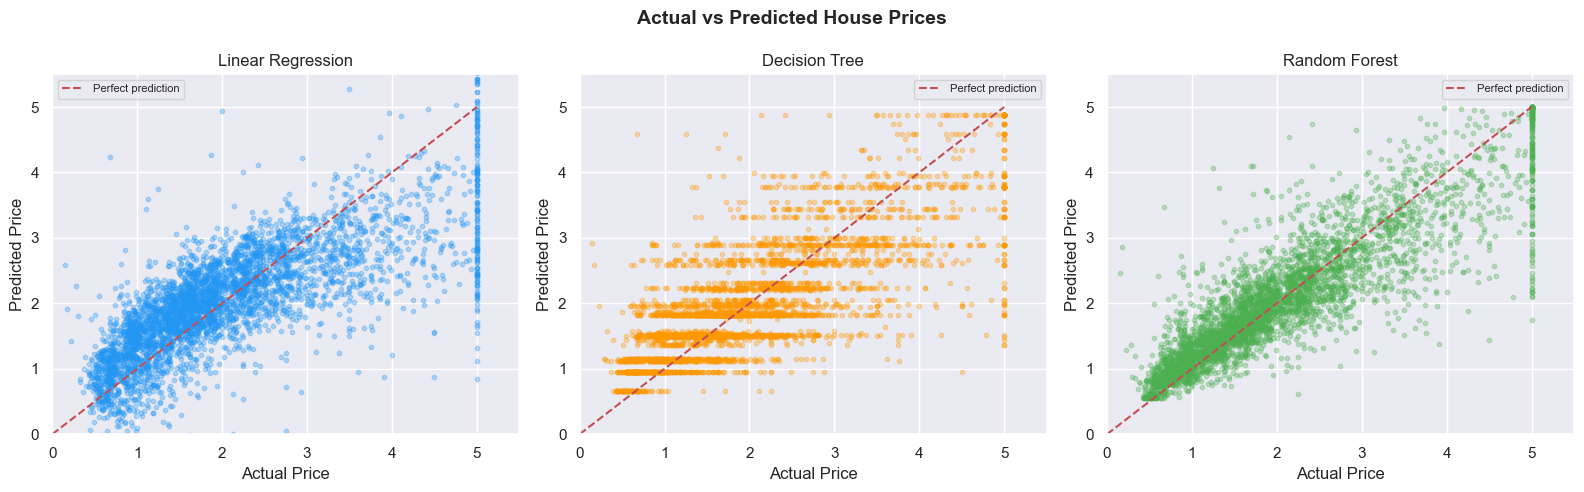

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')

models=[
    ('Linear Regression', y_pred_lr,'#2196F3'),
    ('Decision Tree', y_pred_dt, '#FF9800'),
    ('Random Forest', y_pred_rf,'#4CAF50')
]
for ax, (name, y_pred, color) in zip(axes, models):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    ax.plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 5.5)
    ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

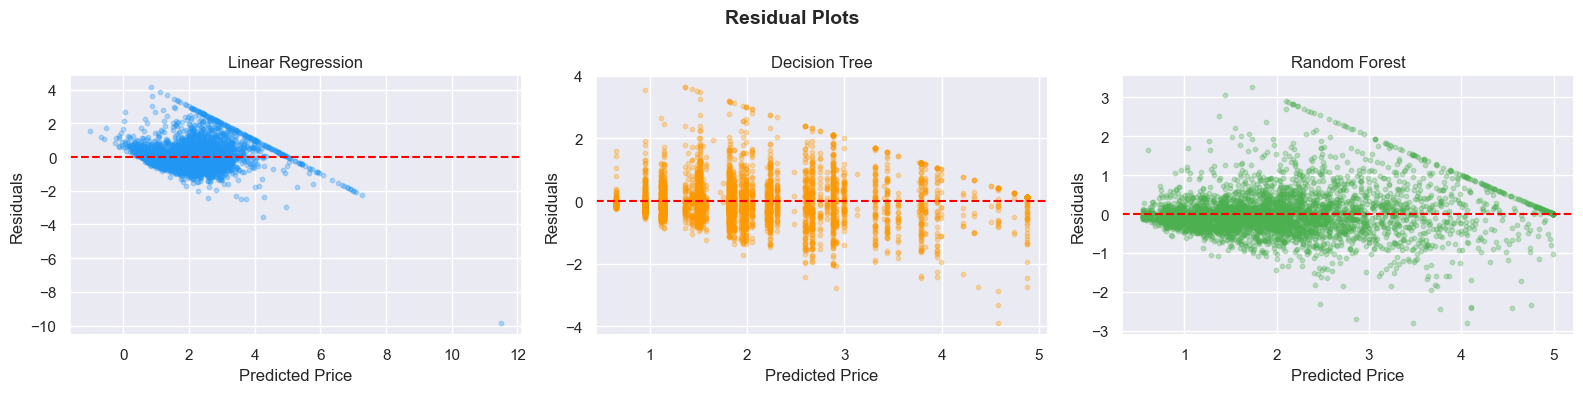

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Residual Plots', fontsize=14, fontweight='bold')

for ax, (name, y_pred, color) in zip(axes, models):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, color=color, s=10)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

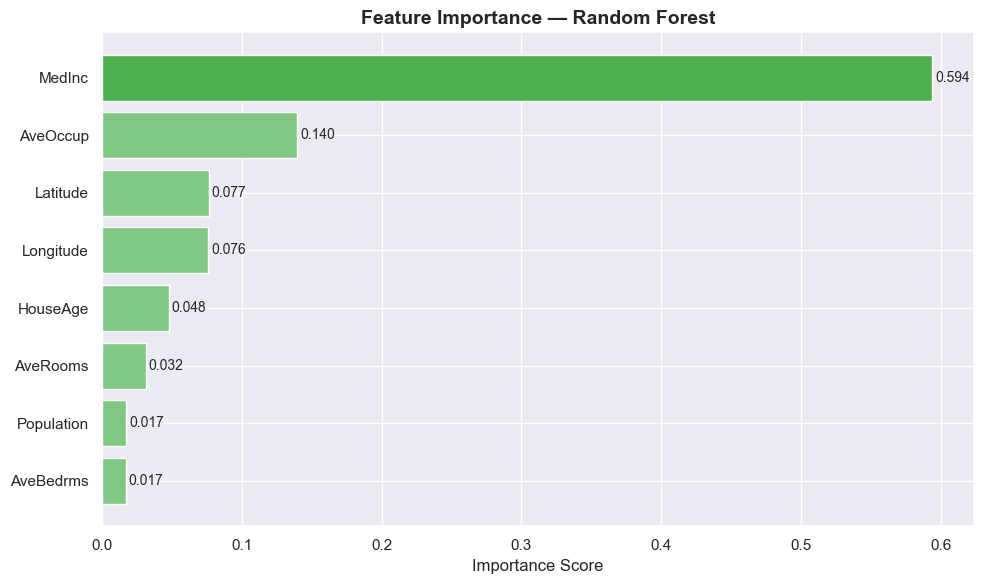

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], 
                feature_importance['Importance'],
                color=['#4CAF50' if x == feature_importance['Importance'].max() 
                       else '#81C784' for x in feature_importance['Importance']])

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, 
                                cv=5, scoring='r2')

print("Cross Validation R² Scores (5-fold):")
print([round(s, 4) for s in cv_scores_rf])
print(f"Mean R²: {cv_scores_rf.mean():.4f}")
print(f"Std R²:  {cv_scores_rf.std():.4f}")

KeyboardInterrupt: 

In [ ]:
print("=" * 55)
print("        HOUSE PRICE PREDICTION — FINAL SUMMARY")
print("=" * 55)

print("\n MODEL PERFORMANCE:")
print(results.to_string(index=False))

print("\n KEY INSIGHTS:")
print("1. MedInc is the strongest predictor of house prices")
print("   (correlation: 0.69, highest feature importance)")
print("2. Random Forest outperforms all models with R²=0.7739")
print("   It handles non-linear relationships better than LR")
print("3. Decision Tree shows horizontal banding — limited to")
print("   64 unique predictions with max_depth=6")
print("4. Latitude & Longitude are important — location matters")
print("   Northern California consistently shows lower prices")

print("\n LIMITATIONS:")
print("- Dataset capped at $500,001 (causes clustering at 5.0)")
print("- No neighbourhood-level features included")
print("- Model may not generalise to other states/countries")

print("\n BEST MODEL: Random Forest")
print(f"  R² Score : 0.7739 (explains 77% of price variance)")
print(f"  RMSE     : 0.5443 ($54,430 average error)")
print(f"  MAE      : 0.3663 ($36,630 average error)")
print("=" * 55)

        HOUSE PRICE PREDICTION — FINAL SUMMARY

 MODEL PERFORMANCE:
            Model   RMSE    MAE  R² Score
Linear Regression 0.7456 0.5332    0.5758
    Decision Tree 0.7052 0.5008    0.6205
    Random Forest 0.5443 0.3663    0.7739

 KEY INSIGHTS:
1. MedInc is the strongest predictor of house prices
   (correlation: 0.69, highest feature importance)
2. Random Forest outperforms all models with R²=0.7739
   It handles non-linear relationships better than LR
3. Decision Tree shows horizontal banding — limited to
   64 unique predictions with max_depth=6
4. Latitude & Longitude are important — location matters
   Northern California consistently shows lower prices

 LIMITATIONS:
- Dataset capped at $500,001 (causes clustering at 5.0)
- No neighbourhood-level features included
- Model may not generalise to other states/countries

 BEST MODEL: Random Forest
  R² Score : 0.7739 (explains 77% of price variance)
  RMSE     : 0.5443 ($54,430 average error)
  MAE      : 0.3663 ($36,630 avera

In [21]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor( max_depth=6, random_state=42)

bagging_model= BaggingRegressor( estimator= tree, n_estimators=100,random_state=42, n_jobs=-1)

bagging_model.fit(X_train_scaled,y_train)


,estimator,DecisionTreeR...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0
